# Imports

In [1]:
import pandas as pd 
import matplotlib.pyplot as plt

# Data imports

In [2]:
campaña = pd.read_csv('../data/processed/campana.csv')
clientes = pd.read_csv('../data/processed/clientes.csv')
devoluciones = pd.read_csv('../data/processed/devoluciones.csv')
lineas_pedido = pd.read_csv('../data/processed/lineas_pedido.csv')
pedidos = pd.read_csv('../data/processed/pedidos.csv')
productos = pd.read_csv('../data/processed/productos.csv')
visitas_web = pd.read_csv('../data/processed/visitas_web.csv')

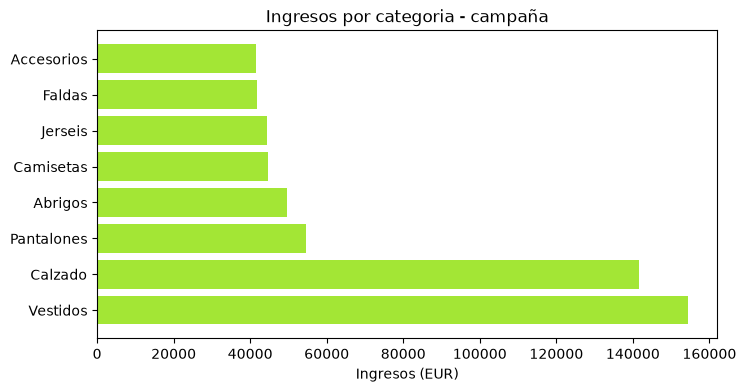

Categoria lider: Vestidos (154292.26 euros)


In [3]:
lp = lineas_pedido.merge(pedidos[['pedido_id', 'campana_id']], on='pedido_id', how='left')
lp = lp.merge(productos[['producto_id', 'categoria']], on='producto_id', how='left')
lp['ingreso'] = lp['cantidad'] * lp['precio_unitario'] * (1 - lp['descuento_pct'])
camp =lp[lp['campana_id'] == 1]

ing_cat = camp.groupby('categoria')['ingreso'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,4))
plt.barh(ing_cat.index, ing_cat.values, color='#a3e635')
plt.title('Revenue by category - campaign')
plt.xlabel('Revenue (EUR)')
plt.savefig('../outputs/figures/ingreso_por_categoria.png')
plt.show()


print(f"Categoria lider: {ing_cat.index[0]} ({ing_cat.iloc[0]:.2f} euros)")

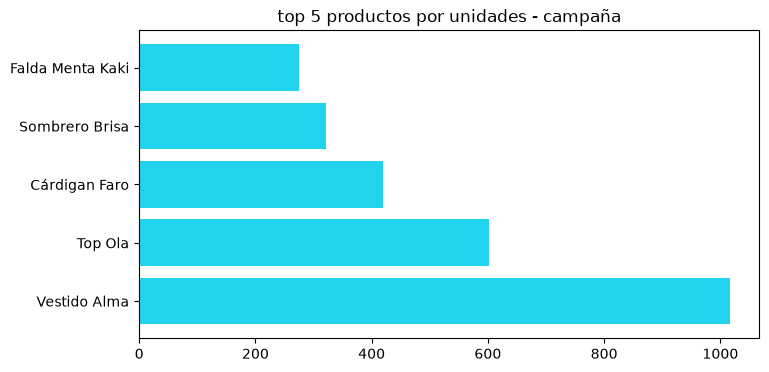

Top 5 productos (unidades) y su tasa de devolución
Vestido Alma: 1016 uds, devolución 42.7
Top Ola: 602 uds, devolución 19.2
Cárdigan Faro: 420 uds, devolución 24.8
Sombrero Brisa: 321 uds, devolución 11.9
Falda Menta Kaki: 275 uds, devolución 36.5


In [4]:
lp = lineas_pedido.merge(pedidos[['pedido_id', 'campana_id']], on='pedido_id', how='left')
lp = lp.merge(productos[['producto_id', 'nombre']], on='producto_id', how='left')
devm = devoluciones[devoluciones['linea_id'].isin(lp['linea_id'])]
devj = devm.merge(lp[['linea_id','nombre']], on='linea_id', how='left')

camp = lp[lp['campana_id'] == 1]
top5 =camp.groupby('nombre')['cantidad'].sum().sort_values(ascending=False).head(5)
lineas_prod = lp.groupby('nombre').size()
dev_prod = devj.groupby('nombre').size()

plt.figure(figsize=(8,4))
plt.barh(top5.index, top5.values, color='#22d3ee')
plt.title('Top 5 products by units - campaign')
plt.savefig('../outputs/figures/productos_por_unidades.png')
plt.show()

print('Top 5 productos (unidades) y su tasa de devolución')
for producto in top5.index: 
    t =dev_prod.get(producto,0) / lineas_prod[producto] * 100
    print(f'{producto}: {int(top5[producto])} uds, devolución {t:.1f}')

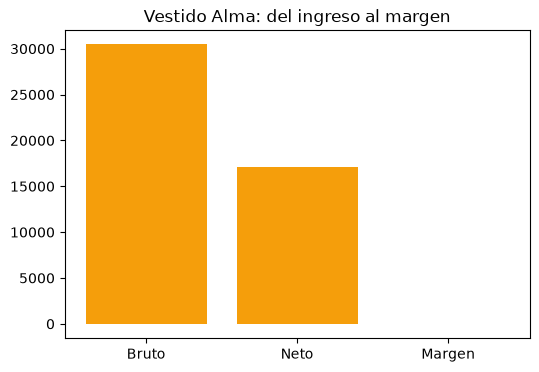

Ingreso bruto del Vestido Alma: 30473.90 EUR
Ingreso neto (tras devoluciones): 17066.59 EUR
Margen neto (tras coste) : -60.31 EUR
CIFRA GRANDE PARA CARMEN: el producto estrella deja -60 EUR


In [5]:
lp = lineas_pedido.merge(pedidos[['pedido_id', 'campana_id']], on='pedido_id', how='left')
lp = lp.merge(productos[['producto_id', 'nombre', 'coste_unitario']], on='producto_id', how='left')
lp['ingreso'] = lp['cantidad'] * lp['precio_unitario'] * (1 - lp['descuento_pct'])

alma = lp[(lp['nombre'] == 'Vestido Alma') & (lp['campana_id'] == 1)]
dev_alma = devoluciones[devoluciones['linea_id'].isin(alma['linea_id'])]
ids_dev = set(dev_alma['linea_id'])
retenidas = alma[~alma['linea_id'].isin(ids_dev)]
devueltas = alma[alma['linea_id'].isin(ids_dev)]

bruto = alma['ingreso'].sum()
neto = bruto - devueltas['ingreso'].sum()
margen = neto - (retenidas['cantidad'] * retenidas['coste_unitario']).sum() 

plt.figure(figsize=(6,4))
plt.bar(['Bruto', 'Neto', 'Margen'], [bruto, neto, margen], color='#f59e0b')
plt.title('Vestido Alma: from revenue to margin')
plt.savefig('../outputs/figures/Vestido_alma_datos.png')
plt.show()

print(f'Ingreso bruto del Vestido Alma: {bruto:.2f} EUR')
print(f'Ingreso neto (tras devoluciones): {neto:.2f} EUR')
print(f'Margen neto (tras coste) : {margen:.2f} EUR')
print(f'CIFRA GRANDE PARA CARMEN: el producto estrella deja {round(margen)} EUR')

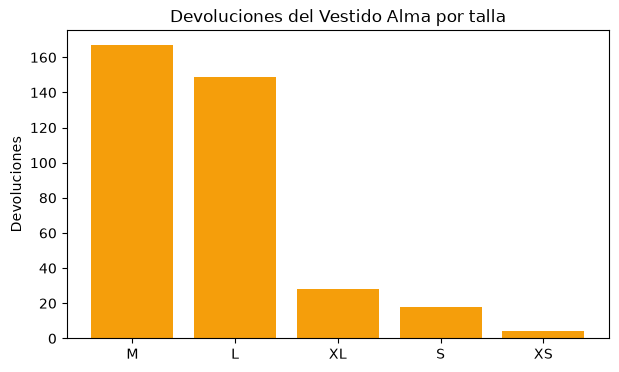

Devoluciones del Alma por talla: 
 M: 167 (45.6%)
 L: 149 (40.7%)
 XL: 28 (7.7%)
 S: 18 (4.9%)
 XS: 4 (1.1%)
Las tallas M y L concentran el 86.3% de las devoluciones


In [6]:
lp = lineas_pedido.merge(productos[['producto_id', 'nombre']], on='producto_id', how='left')
alma = lp[lp['nombre'] == 'Vestido Alma']
dev_alma = devoluciones[devoluciones['linea_id'].isin(alma['linea_id'])].copy()

vc = dev_alma['talla_norm'].value_counts()
tot = len(dev_alma)

plt.figure(figsize=(7,4))
plt.bar(vc.index, vc.values, color ='#f59e0b')
plt.title('Vestido Alma returns by size')
plt.ylabel('Returns')
plt.savefig('../outputs/figures/devoluciones_vestido_alma.png')
plt.show()

print('Devoluciones del Alma por talla: ')
for t in vc.index: 
    print(f' {t}: {vc[t]} ({vc[t]/tot*100:.1f}%)')

ml = vc.get('M',0) + vc.get('L', 0)
print("Las tallas M y L concentran el %.1f%% de las devoluciones" % (ml/tot*100))

In [9]:
lp = lineas_pedido.merge(pedidos[['pedido_id','campana_id']], on='pedido_id', how='left')
lp = lp.merge(productos[['producto_id','categoria']], on='producto_id', how='left')
lp['ingreso'] = lp['cantidad'] * lp['precio_unitario'] * (1 - lp['descuento_pct'])
camp = lp[lp['campana_id'] == 1].copy()

devm = devoluciones[devoluciones['linea_id'].isin(camp['linea_id'])]
ids_dev = set(devm['linea_id'])
camp['devuelta'] = camp['linea_id'].isin(ids_dev)

bruto_cat = camp.groupby('categoria')['ingreso'].sum()
neto_cat = camp[~camp['devuelta']].groupby('categoria')['ingreso'].sum()   # <- completa

tabla = pd.DataFrame({'bruto': bruto_cat, 'neto': neto_cat})
tabla['retenido_pct'] = tabla['neto'] / tabla['bruto'] * 100
tabla = tabla.sort_values('neto', ascending=False)
for c in tabla.head(4).index:
    print(f"{c}: neto={tabla.loc[c,'neto']:.2f} EUR (retiene {tabla.loc[c,'retenido_pct']:.1f}% del bruto)")

Vestidos: neto=99750.25 EUR (retiene 64.7% del bruto)
Calzado: neto=93101.84 EUR (retiene 65.7% del bruto)
Pantalones: neto=38002.69 EUR (retiene 69.8% del bruto)
Abrigos: neto=36797.82 EUR (retiene 74.3% del bruto)
